# Conditional Workflow

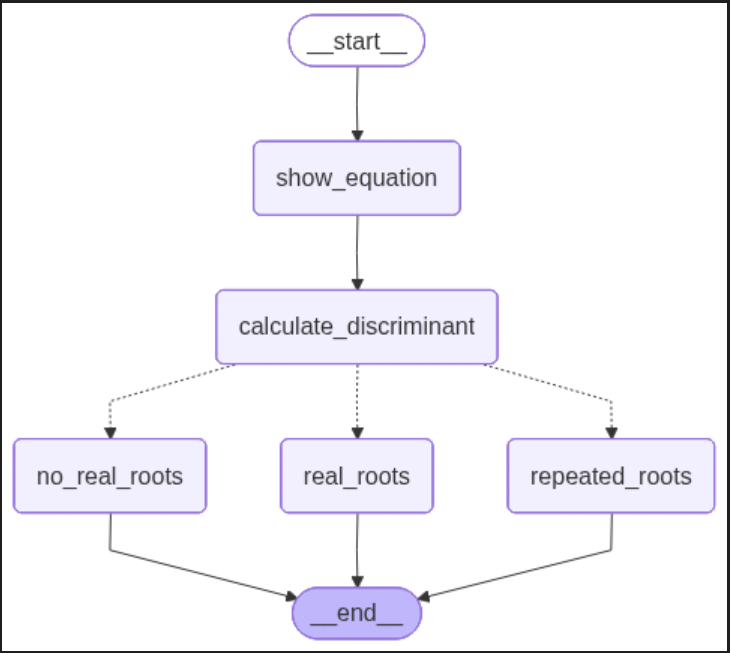

In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [3]:
class QuadraticState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: int
    result: str

In [ ]:
def show_equation(state: QuadraticState):
    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'
    return {'equation': equation}

def calculate_discriminant(state: QuadraticState):
    discriminant = state['b']**2 - (4*state['a']*state['c'])
    return {'discriminant': discriminant}

def real_roots(state: QuadraticState):
    root1 = (-state["b"]+state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"]-state["discriminant"]**0.5)/(2*state["a"])
    result = f"The roots are {root1} and {root2}"
    return {'result': result}

def repeated_roots(state: QuadraticState):
    root = (-state["b"])/(2*state["a"])
    result = f"Only repeated root is {root}"
    return {'result': result}

def no_real_roots(state:QuadraticState):
    result = f"No real roots"
    return {'result':result}
                  
# use for conditional checks
def check_condition(state: QuadraticState)->Literal['real_roots', 'repeated_roots', 'no_real_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'

In [21]:
graph = StateGraph(QuadraticState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

In [23]:
workflow = graph.compile()

In [24]:
initial_state={
    'a': 4,
    'b':-5,
    'c':-4
}
final_state = workflow.invoke(initial_state)

In [25]:
final_state

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2-5x-4',
 'discriminant': 89,
 'result': 'The roots are 1.8042476415070754 and -0.5542476415070754'}

# LLM based Conditional Workflow